In [1]:
import saspy

sas = saspy.SASsession()
sas

Using SAS Config named: oda_euw1
SAS Connection established. Subprocess id is 10280



Access Method         = IOM
SAS Config name       = oda_euw1
SAS Config file       = C:\Users\yzdom/.config/saspy\sascfg_personal.py
WORK Path             = /saswork/SAS_workBCA600017433_odaws01-euw1.oda.sas.com/SAS_work42FF00017433_odaws01-euw1.oda.sas.com/
SAS Version           = 9.04.01M8P02222023
SASPy Version         = 5.103.0
Teach me SAS          = False
Batch                 = False
Results               = Pandas
SAS Session Encoding  = utf-8
Python Encoding value = utf-8
SAS process Pid value = 95283
SASsession started    = Tue May 12 12:08:03 2026


 ## data
 ####################################################################################################

In [2]:
tbl = "sashelp.heart"

In [ ]:
sas.submitLST(
    f"proc contents data={tbl};run;",
    method="listonly",
)

In [ ]:
sas.submitLST(
    f"""
proc print data={tbl} (obs=5);
run;
""",
    method="listonly",
)

Obs,Status,DeathCause,AgeCHDdiag,Sex,AgeAtStart,Height,Weight,Diastolic,Systolic,MRW,Smoking,AgeAtDeath,Cholesterol,Chol_Status,BP_Status,Weight_Status,Smoking_Status
1,Dead,Other,.,Female,29,62.50,140,78,124,121,0,55,.,,Normal,Overweight,Non-smoker
2,Dead,Cancer,.,Female,41,59.75,194,92,144,183,0,57,181,Desirable,High,Overweight,Non-smoker
3,Alive,,.,Female,57,62.25,132,90,170,114,10,.,250,High,High,Overweight,Moderate (6-15)
4,Alive,,.,Female,39,65.75,158,80,128,123,0,.,242,High,Normal,Overweight,Non-smoker
5,Alive,,.,Male,42,66.00,156,76,110,116,20,.,281,High,Optimal,Overweight,Heavy (16-25)


 ## tables
 ####################################################################################################

In [ ]:
# tables

In [3]:
sas.submitLST(
    f"""
proc freq data={tbl};
    tables smoking_status;
run;
""",
    method="listonly",
)

In [ ]:
sas.submitLST(
    f"""
proc freq data={tbl};
    tables smoking_status * status / chisq;
run;
""",
    method="listonly",
)


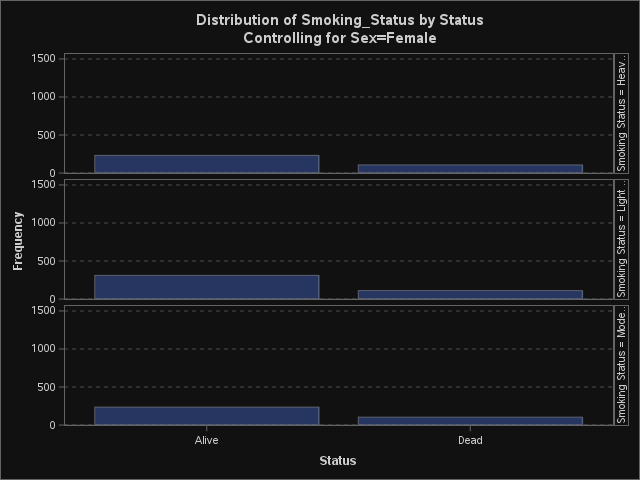
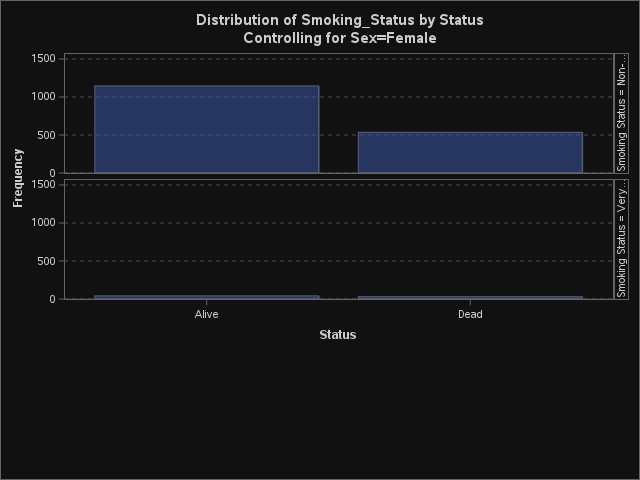
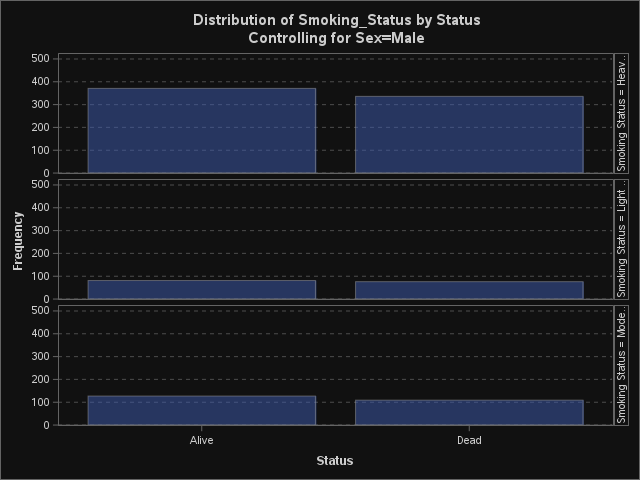
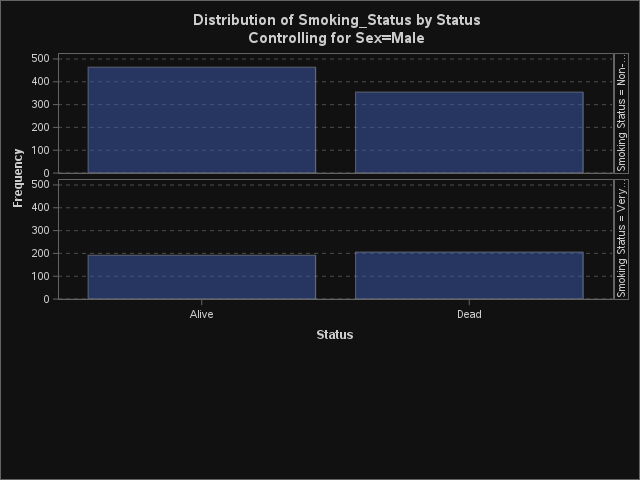

In [ ]:
# plots
sas.submitLST(
    f"""
proc freq data={tbl};
    tables sex * smoking_status * status / 
    chisq cmh plots(only)=freqplot;
run;
""",
    method="listonly",
)

In [ ]:
# measures
sas.submitLST(
    f"""
proc freq data={tbl};
    tables smoking_status * status / measures;
run;
""",
    method="listonly",
)

In [ ]:
# test
sas.submitLST(
    f"""
proc freq data={tbl};
    tables smoking_status * status;
    test smdrc;
run;
""",
    method="listonly",
)

### template candidate

In [ ]:
# cross all and extract df

In [10]:
sas.submitLST(
    f"""
proc freq data={tbl};
    tables smoking_status * status / all;
    output out=work._tmp_freq measures;
run;
""",
    method="listonly",
)
_lib, _tbl = "work._tmp_freq".split(".")
df = sas.sd2df(_tbl, _lib)
df.T

,0
N,5173.000000
_GAMMA_,0.016523
E_GAMMA,0.022660
_KENTB_,0.009517
E_KENTB,0.013043
_STUTC_,0.010876
E_STUTC,0.014907
_SMDCR_,0.007856
E_SMDCR,0.010766
_SMDRC_,0.011528


In [ ]:
# cross all and plot


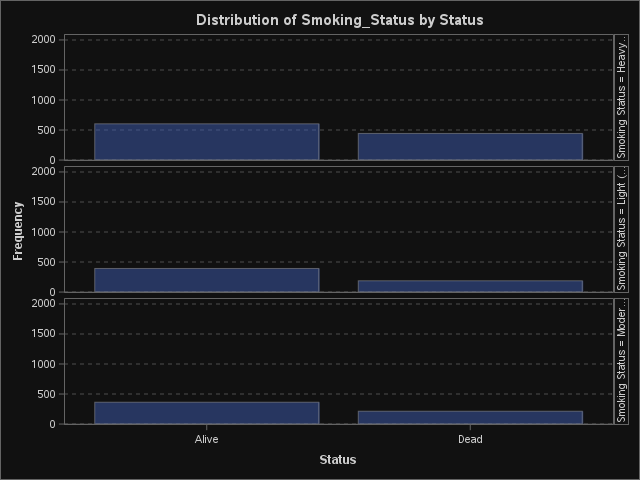
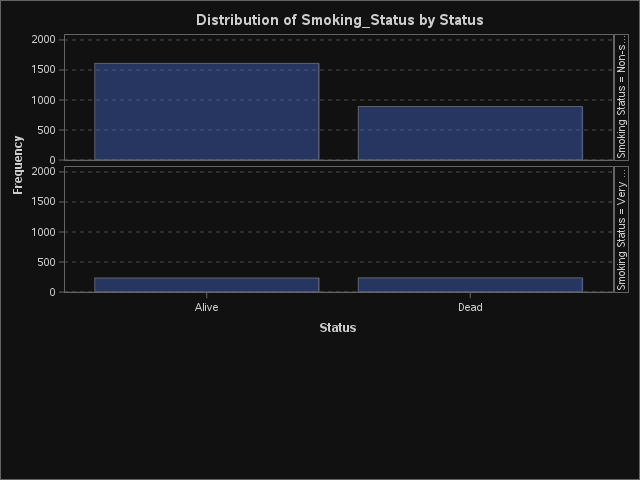

In [21]:
sas.submitLST(
    f"""
proc freq data={tbl};
    tables smoking_status * status / chisq plots(only)=freqplot out=work._freq outpct;
run;
""",
    method="listonly",
)


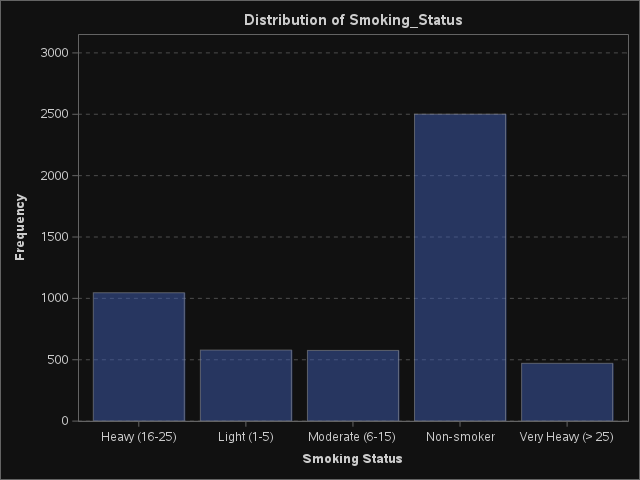

In [12]:
sas.submitLST(
    f"""
proc freq data={tbl};
    tables smoking_status / chisq plots(only)=freqplot;
run;
""",
    method="listonly",
)

 ## stats example - smdrc
 ####################################################################################################

In [ ]:
# smdrc table ods
sas.submitLST(
    f"""
ods select none;
ods output Measures=work._measures5;
proc freq data={tbl};
    tables smoking * status / measures;
run;
ods output close;
ods select all;
""",
    method="listandlog",
)

sas.submitLST(
    f"""
proc print data=work._measures5 (obs=20 where=(Statistic="Somers' D R|C"));
run;
""",
    method="listonly",
)

17                                                         The SAS System                           Monday, May 11, 2026 11:16:00 PM

105        ods listing close;ods html5 (id=saspy_internal) file=_tomods1 options(bitmap_mode='inline') device=svg style=Raven; ods
105      ! graphics on / outputfmt=png;
106        
107        
108        ods select none;
109        ods output Measures=work._measures5;
110        proc freq data=sashelp.heart;
111            tables smoking * status / measures;
112        run;
113        ods output close;
114        ods select all;
115        
116        
117        
118        ods html5 (id=saspy_internal) close;ods listing;
119        
18                                                         The SAS System                           Monday, May 11, 2026 11:16:00 PM

120        


Obs,Table,Statistic,Value,ASE,Control
5,Table Smoking * Status,Somers' D R|C,0.0899,0.0157,


In [ ]:
# smdrc output
sas.submitLST(
    f"""
proc freq data={tbl} noprint;
    tables smoking * status / measures;
    output out=work._measures5 smdrc;
run;
""",
    method="listandlog",
)
sas.submitLST(
    f"""
proc print data=work._measures5 (obs=20);
run;
""",
    method="listonly",
)

21                                                         The SAS System                           Monday, May 11, 2026 11:16:00 PM

136        ods listing close;ods html5 (id=saspy_internal) file=_tomods1 options(bitmap_mode='inline') device=svg style=Raven; ods
136      ! graphics on / outputfmt=png;
137        
138        
139        proc freq data=sashelp.heart;
140            tables smoking * status / measures;
141            output out=work._measures5 smdrc;
142        run;
143        
144        
145        
146        ods html5 (id=saspy_internal) close;ods listing;
147        
22                                                         The SAS System                           Monday, May 11, 2026 11:16:00 PM

148        


Obs,_SMDRC_,E_SMDRC
1,0.089860,0.015691



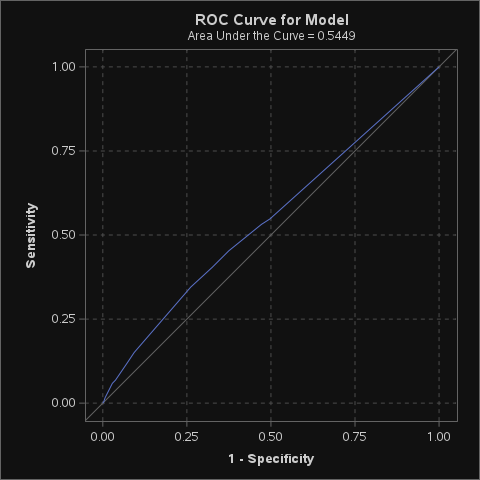

In [ ]:
# check
sas.submitLST(
    f"""
proc logistic data={tbl} plots(only)=roc;
    where status in ('Alive', 'Dead');
    model status(event='Dead') = smoking;
    output out=work._pred p=phat;
run;
""",
    method="listonly",
)